In [1]:
# 1. SETUP & CONFIG

import os, glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
from google.colab import drive

print("🔄 Mounting Google Drive...")
drive.mount("/content/drive", force_remount=True)

# Paths
BASE_ROOT = "/content/drive/MyDrive/capture24"
RESEARCH_GLOB = os.path.join(BASE_ROOT, "processed_research", "*_research.npz")

# Device / hyperparams
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 256
NUM_WORKERS = 0
MAX_EPOCHS_SSL = 20
MAX_EPOCHS_MT = 20
PATIENCE = 5
LEARNING_RATE = 1e-4

# Patching for 10 s @ 100 Hz: (1000,3) → (50,20,3) → (50,60)
WINDOW_LEN = 1000
PATCH_SIZE = 20
NUM_PATCHES = WINDOW_LEN // PATCH_SIZE  # 50
PATCH_DIM = PATCH_SIZE * 3             # 60

# Labels (CAPTURE‑24 grouped)
CLASSES = ['sleep', 'sit-stand', 'walking', 'mixed', 'bicycling', 'vehicle', 'unknown']
CLASS_TO_ID = {c: i for i, c in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)
UNKNOWN_ID = CLASS_TO_ID['unknown']

print("✅ Config ready. Device:", DEVICE)


🔄 Mounting Google Drive...
Mounted at /content/drive
✅ Config ready. Device: cuda


In [2]:
# 2. LOAD RESEARCH WINDOWS & SPLIT

print("🔍 Searching for research NPZ...")
found_files = glob.glob(RESEARCH_GLOB)
if not found_files:
    found_files = glob.glob(os.path.join(BASE_ROOT, "**", "*_research.npz"), recursive=True)

if not found_files:
    raise ValueError("❌ No *_research.npz files found.")

valid_files = [f for f in found_files if os.path.getsize(f) > 1000]
print(f"✅ Found {len(valid_files)} valid research files.")

# Participant‑level split (group‑held‑out)
pids = sorted({os.path.basename(f).split("_")[0] for f in valid_files})
split_idx = int(0.8 * len(pids))
train_pids = set(pids[:split_idx])
test_pids  = set(pids[split_idx:])

train_files = [f for f in valid_files if os.path.basename(f).split("_")[0] in train_pids]
test_files  = [f for f in valid_files if os.path.basename(f).split("_")[0] in test_pids]

print(f"🚀 Participant split: {len(train_pids)} train / {len(test_pids)} test")
print(f"   Files: {len(train_files)} train / {len(test_files)} test")


🔍 Searching for research NPZ...
✅ Found 151 valid research files.
🚀 Participant split: 120 train / 31 test
   Files: 120 train / 31 test


In [3]:
# 3. DATASET + AUGMENTATIONS

class Augmentations:
    @staticmethod
    def apply(x: torch.Tensor) -> torch.Tensor:
        # x: (P, D)
        if torch.rand(1) < 0.5:   # jitter
            x = x + torch.randn_like(x) * 0.03
        if torch.rand(1) < 0.5:   # scaling
            scale = 1.0 + torch.randn(1).item() * 0.1
            x = x * scale
        if torch.rand(1) < 0.3:   # simple planar rotation on x,y
            theta = (torch.rand(1).item() - 0.5) * (np.pi / 4)
            c, s = np.cos(theta), np.sin(theta)
            x_xyz = x.view(NUM_PATCHES, PATCH_SIZE, 3)
            x0, x1, x2 = x_xyz[...,0], x_xyz[...,1], x_xyz[...,2]
            x0n = c * x0 - s * x1
            x1n = s * x0 + c * x1
            x_xyz = torch.stack([x0n, x1n, x2], dim=-1)
            x = x_xyz.view(NUM_PATCHES, PATCH_DIM)
        return x

class MultiTaskDataset(Dataset):
    def __init__(self, file_paths, mode='train'):
        self.mode = mode
        xs, ys = [], []

        print(f"   📂 Loading {len(file_paths)} files for {mode}...")
        skipped = 0
        for f in file_paths:
            try:
                d = np.load(f)
                x, y = d["x"], d["y"]   # x: (N,1000,3), y: (N,)
                if x.ndim != 3 or x.shape[1] != WINDOW_LEN or x.shape[2] != 3:
                    skipped += 1
                    continue
                n = x.shape[0]
                x_resh = x.reshape(n, NUM_PATCHES, PATCH_SIZE, 3).reshape(n, NUM_PATCHES, PATCH_DIM)
                xs.append(x_resh)
                ys.append(y)
            except Exception:
                skipped += 1

        if not xs:
            raise ValueError(f"❌ No valid data for {mode}.")

        self.data_x = torch.tensor(np.concatenate(xs, axis=0), dtype=torch.float32)
        self.data_y = torch.tensor(np.concatenate(ys, axis=0), dtype=torch.long)
        print(f"      ✅ Loaded {len(self)} windows ({skipped} files skipped)")

    def __len__(self):
        return len(self.data_x)

    def __getitem__(self, idx):
        x = self.data_x[idx]          # (50,60)
        y = self.data_y[idx]

        if self.mode == 'train':
            x = Augmentations.apply(x)

        # SSL mask: random ~15% patches, contiguous block
        ssl_mask = torch.zeros(NUM_PATCHES, dtype=torch.bool)
        span = max(1, int(0.15 * NUM_PATCHES))
        start = torch.randint(0, NUM_PATCHES - span + 1, (1,)).item()
        ssl_mask[start:start+span] = True

        # Forecast mask: last 10 patches (2 s)
        fc_mask = torch.zeros(NUM_PATCHES, dtype=torch.bool)
        fc_mask[-10:] = True

        return x, ssl_mask, fc_mask, y

    def get_class_weights(self):
        labels = self.data_y.numpy()
        classes = np.unique(labels)
        weights = compute_class_weight("balanced", classes=classes, y=labels)
        w = torch.ones(NUM_CLASSES, dtype=torch.float32)
        for c, wt in zip(classes, weights):
            if c < NUM_CLASSES:
                w[int(c)] = float(wt)
        return w.to(DEVICE)


In [4]:
# 4. MODEL: BERT‑LIKE TRANSFORMER

D_MODEL = 256
N_HEAD = 8
NUM_LAYERS = 6
ENC_DROPOUT = 0.2
HEAD_DROPOUT = 0.3

class ResearchTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Linear(PATCH_DIM, D_MODEL)
        self.pos = nn.Parameter(torch.randn(1, NUM_PATCHES, D_MODEL) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL,
            nhead=N_HEAD,
            dim_feedforward=4*D_MODEL,
            dropout=ENC_DROPOUT,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=NUM_LAYERS)
        self.dropout = nn.Dropout(HEAD_DROPOUT)
        self.head_ssl = nn.Linear(D_MODEL, PATCH_DIM)
        self.head_har = nn.Linear(D_MODEL, NUM_CLASSES)

    def encode(self, x):
        h = self.emb(x) + self.pos
        h = self.encoder(h)
        return h

    def forward(self, x):
        h = self.encode(x)
        h_drop = self.dropout(h)
        recon = self.head_ssl(h_drop)
        logits = self.head_har(h_drop.mean(dim=1))
        return recon, logits


In [5]:
# 5. SSL PRETRAINING (ENCODER ONLY)

train_ds_ssl = MultiTaskDataset(train_files, mode='train')
val_ds_ssl   = MultiTaskDataset(test_files,  mode='val')

train_loader_ssl = DataLoader(train_ds_ssl, batch_size=BATCH_SIZE,
                              shuffle=True,  num_workers=NUM_WORKERS)
val_loader_ssl   = DataLoader(val_ds_ssl,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=NUM_WORKERS)

ssl_model = ResearchTransformer().to(DEVICE)
opt_ssl = optim.AdamW(ssl_model.parameters(), lr=LEARNING_RATE)
scheduler_ssl = optim.lr_scheduler.ReduceLROnPlateau(opt_ssl, mode='min',
                                                     factor=0.5, patience=2)
crit_mse = nn.MSELoss()

best_ssl_val = float("inf")
pat = 0

print("\n--- 🚀 Stage 1: SSL Pretraining ---")
for epoch in range(MAX_EPOCHS_SSL):
    ssl_model.train()
    losses = []
    for x, m_ssl, _, _ in train_loader_ssl:
        x, m_ssl = x.to(DEVICE), m_ssl.to(DEVICE)

        x_in = x.clone()
        x_in[m_ssl.unsqueeze(-1).expand_as(x)] = 0

        recon, _ = ssl_model(x_in)
        loss = crit_mse(recon[m_ssl], x[m_ssl])

        opt_ssl.zero_grad()
        loss.backward()
        opt_ssl.step()
        losses.append(loss.item())

    train_loss = float(np.mean(losses))

    ssl_model.eval()
    val_losses = []
    with torch.no_grad():
        for x, m_ssl, _, _ in val_loader_ssl:
            x, m_ssl = x.to(DEVICE), m_ssl.to(DEVICE)
            x_in = x.clone()
            x_in[m_ssl.unsqueeze(-1).expand_as(x)] = 0
            recon, _ = ssl_model(x_in)
            val_losses.append(crit_mse(recon[m_ssl], x[m_ssl]).item())
    val_loss = float(np.mean(val_losses))
    scheduler_ssl.step(val_loss)

    print(f"Epoch {epoch+1}/{MAX_EPOCHS_SSL} | SSL Train: {train_loss:.4f} | Val: {val_loss:.4f}")

    if val_loss < best_ssl_val - 1e-4:
        best_ssl_val = val_loss
        pat = 0
        torch.save(ssl_model.state_dict(), "best_ssl_encoder.pth")
    else:
        pat += 1
        if pat >= PATIENCE:
            print("🛑 SSL early stopping")
            break

print("✅ Best SSL val loss:", best_ssl_val)


   📂 Loading 120 files for train...
      ✅ Loaded 1124194 windows (0 files skipped)
   📂 Loading 31 files for val...
      ✅ Loaded 279621 windows (0 files skipped)

--- 🚀 Stage 1: SSL Pretraining ---
Epoch 1/20 | SSL Train: 0.0397 | Val: 0.0342
Epoch 2/20 | SSL Train: 0.0312 | Val: 0.0325
Epoch 3/20 | SSL Train: 0.0271 | Val: 0.0273
Epoch 4/20 | SSL Train: 0.0253 | Val: 0.0265
Epoch 5/20 | SSL Train: 0.0245 | Val: 0.0257
Epoch 6/20 | SSL Train: 0.0242 | Val: 0.0255
Epoch 7/20 | SSL Train: 0.0239 | Val: 0.0253
Epoch 8/20 | SSL Train: 0.0237 | Val: 0.0252
Epoch 9/20 | SSL Train: 0.0234 | Val: 0.0245
Epoch 10/20 | SSL Train: 0.0231 | Val: 0.0241
Epoch 11/20 | SSL Train: 0.0230 | Val: 0.0242
Epoch 12/20 | SSL Train: 0.0228 | Val: 0.0242
Epoch 13/20 | SSL Train: 0.0227 | Val: 0.0238
Epoch 14/20 | SSL Train: 0.0225 | Val: 0.0234
Epoch 15/20 | SSL Train: 0.0223 | Val: 0.0234
Epoch 16/20 | SSL Train: 0.0223 | Val: 0.0232
Epoch 17/20 | SSL Train: 0.0221 | Val: 0.0233
Epoch 18/20 | SSL Train: 

In [6]:
# 6. MULTITASK FINETUNE (FORECAST + HAR)

train_ds = MultiTaskDataset(train_files, mode='train')
test_ds  = MultiTaskDataset(test_files,  mode='val')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)

mt_model = ResearchTransformer().to(DEVICE)
mt_model.load_state_dict(torch.load("best_ssl_encoder.pth"), strict=False)

class_weights = train_ds.get_class_weights()
crit_ce = nn.CrossEntropyLoss(weight=class_weights)

opt = optim.AdamW(mt_model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min',
                                                 factor=0.5, patience=2)

best_val = float("inf")
pat = 0

print("\n--- 🚀 Stage 2: Multitask Fine‑tune ---")
for epoch in range(MAX_EPOCHS_MT):
    mt_model.train()
    train_losses = []

    for x, m_ssl, m_fc, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        m_ssl = m_ssl.to(DEVICE)
        m_fc = m_fc.to(DEVICE)

        # SSL branch
        x_ssl = x.clone()
        x_ssl[m_ssl.unsqueeze(-1).expand_as(x)] = 0
        recon_ssl, logits = mt_model(x_ssl)
        ssl_loss = crit_mse(recon_ssl[m_ssl], x[m_ssl])

        # Forecast branch
        x_fc = x.clone()
        x_fc[m_fc.unsqueeze(-1).expand_as(x)] = 0
        recon_fc, _ = mt_model(x_fc)
        fc_loss = crit_mse(recon_fc[m_fc], x[m_fc])

        # HAR
        har_loss = crit_ce(logits, y)

        loss = ssl_loss + 0.5 * fc_loss + 0.5 * har_loss

        opt.zero_grad()
        loss.backward()
        opt.step()
        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))

    # Validation
    mt_model.eval()
    val_losses = []
    with torch.no_grad():
        for x, m_ssl, m_fc, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            m_ssl = m_ssl.to(DEVICE)
            m_fc = m_fc.to(DEVICE)

            x_ssl = x.clone()
            x_ssl[m_ssl.unsqueeze(-1).expand_as(x)] = 0
            recon_ssl, logits = mt_model(x_ssl)
            ssl_loss = crit_mse(recon_ssl[m_ssl], x[m_ssl])

            x_fc = x.clone()
            x_fc[m_fc.unsqueeze(-1).expand_as(x)] = 0
            recon_fc, _ = mt_model(x_fc)
            fc_loss = crit_mse(recon_fc[m_fc], x[m_fc])

            har_loss = crit_ce(logits, y)
            val_losses.append((ssl_loss + 0.5 * fc_loss + 0.5 * har_loss).item())

    val_loss = float(np.mean(val_losses))
    scheduler.step(val_loss)
    print(f"Epoch {epoch+1}/{MAX_EPOCHS_MT} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | LR: {opt.param_groups[0]['lr']:.2e}")

    if val_loss < best_val - 1e-4:
        best_val = val_loss
        pat = 0
        torch.save(mt_model.state_dict(), "best_multitask.pth")
    else:
        pat += 1
        if pat >= PATIENCE:
            print("🛑 Multitask early stopping")
            break

print("✅ Best multitask val loss:", best_val)


   📂 Loading 120 files for train...
      ✅ Loaded 1124194 windows (0 files skipped)
   📂 Loading 31 files for val...
      ✅ Loaded 279621 windows (0 files skipped)

--- 🚀 Stage 2: Multitask Fine‑tune ---
Epoch 1/20 | Train: 0.6287 | Val: 0.6237 | LR: 1.00e-04
Epoch 2/20 | Train: 0.5924 | Val: 0.6163 | LR: 1.00e-04
Epoch 3/20 | Train: 0.5780 | Val: 0.6206 | LR: 1.00e-04
Epoch 4/20 | Train: 0.5687 | Val: 0.6194 | LR: 1.00e-04
Epoch 5/20 | Train: 0.5625 | Val: 0.6110 | LR: 1.00e-04
Epoch 6/20 | Train: 0.5554 | Val: 0.6090 | LR: 1.00e-04
Epoch 7/20 | Train: 0.5509 | Val: 0.6159 | LR: 1.00e-04
Epoch 8/20 | Train: 0.5457 | Val: 0.6247 | LR: 1.00e-04
Epoch 9/20 | Train: 0.5412 | Val: 0.6256 | LR: 5.00e-05
Epoch 10/20 | Train: 0.5263 | Val: 0.6059 | LR: 5.00e-05
Epoch 11/20 | Train: 0.5212 | Val: 0.6080 | LR: 5.00e-05
Epoch 12/20 | Train: 0.5184 | Val: 0.6204 | LR: 5.00e-05
Epoch 13/20 | Train: 0.5151 | Val: 0.6163 | LR: 2.50e-05
Epoch 14/20 | Train: 0.5046 | Val: 0.6082 | LR: 2.50e-05
Epoch

In [7]:
# 7. FINAL EVALUATION

mt_model.load_state_dict(torch.load("best_multitask.pth"))
mt_model.eval()

y_true, y_pred = [], []
fc_errors = {"0.5s": [], "1.0s": [], "2.0s": []}
baseline_errs = []

with torch.no_grad():
    for x, _, m_fc, y in test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        m_fc = m_fc.to(DEVICE)

        # Model forecast
        x_in = x.clone()
        x_in[m_fc.unsqueeze(-1).expand_as(x)] = 0
        recon, logits = mt_model(x_in)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(logits.argmax(1).cpu().numpy())

        diff = torch.abs(recon - x)
        fc_errors["0.5s"].append(diff[:, -10, :].mean().item())
        fc_errors["1.0s"].append(diff[:, -5,  :].mean().item())
        fc_errors["2.0s"].append(diff[:, -1,  :].mean().item())

        # Persistence baseline: repeat patch -11 for patches -10..-1
        last_obs = x[:, -11, :].unsqueeze(1)  # (B,1,D)
        baseline_diff = torch.abs(last_obs - x[:, -10:, :])
        baseline_errs.append(baseline_diff.mean().item())

print("\n1. Forecasting vs baseline (MAE):")
for h, vals in fc_errors.items():
    print(f"   Model @ {h}: {np.mean(vals):.4f}")
base_mae = np.mean(baseline_errs)
print(f"   Baseline Avg: {base_mae:.4f}")
improve = (base_mae - np.mean(fc_errors["1.0s"])) / base_mae * 100
print(f"   → Improvement vs baseline @1.0s: {improve:.1f}%")

print("\n2. HAR classification (known classes only):")
y_true = np.array(y_true)
y_pred = np.array(y_pred)
mask = y_true != UNKNOWN_ID

if mask.sum() > 0:
    y_true_k = y_true[mask]
    y_pred_k = y_pred[mask]
    print(classification_report(
        y_true_k, y_pred_k,
        labels=list(range(NUM_CLASSES-1)),
        target_names=CLASSES[:-1],
        zero_division=0
    ))
    acc = (y_true_k == y_pred_k).mean() * 100
    print(f"Overall accuracy (known): {acc:.2f}%")
else:
    print("⚠️ All test samples were 'unknown'")

print("\n✅ End‑to‑end pipeline complete.")



1. Forecasting vs baseline (MAE):
   Model @ 0.5s: 0.0578
   Model @ 1.0s: 0.0802
   Model @ 2.0s: 0.0833
   Baseline Avg: 0.1076
   → Improvement vs baseline @1.0s: 25.5%

2. HAR classification (known classes only):
              precision    recall  f1-score   support

       sleep       0.89      0.93      0.91     66549
   sit-stand       0.78      0.72      0.75     62883
     walking       0.35      0.58      0.43     14322
       mixed       0.64      0.42      0.51     34708
   bicycling       0.42      0.86      0.57      1666
     vehicle       0.53      0.59      0.55      6344

   micro avg       0.73      0.73      0.73    186472
   macro avg       0.60      0.68      0.62    186472
weighted avg       0.75      0.73      0.73    186472

Overall accuracy (known): 72.62%

✅ End‑to‑end pipeline complete.


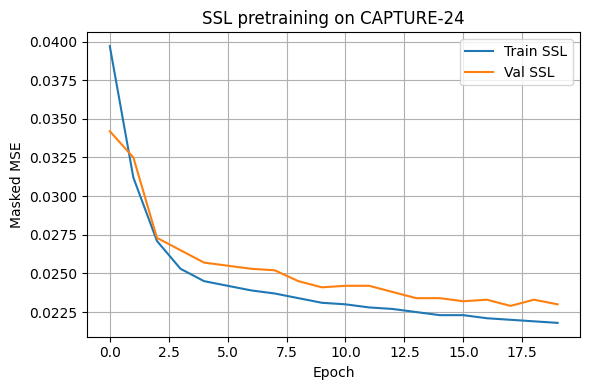

In [8]:
import matplotlib.pyplot as plt

# Manually enter or log these during training
ssl_train_hist = [0.0397,0.0312,0.0271,0.0253,0.0245,0.0242,0.0239,0.0237,0.0234,0.0231,
                  0.0230,0.0228,0.0227,0.0225,0.0223,0.0223,0.0221,0.0220,0.0219,0.0218]
ssl_val_hist   = [0.0342,0.0325,0.0273,0.0265,0.0257,0.0255,0.0253,0.0252,0.0245,0.0241,
                  0.0242,0.0242,0.0238,0.0234,0.0234,0.0232,0.0233,0.0229,0.0233,0.0230]

plt.figure(figsize=(6,4))
plt.plot(ssl_train_hist, label="Train SSL")
plt.plot(ssl_val_hist,   label="Val SSL")
plt.xlabel("Epoch")
plt.ylabel("Masked MSE")
plt.title("SSL pretraining on CAPTURE‑24")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


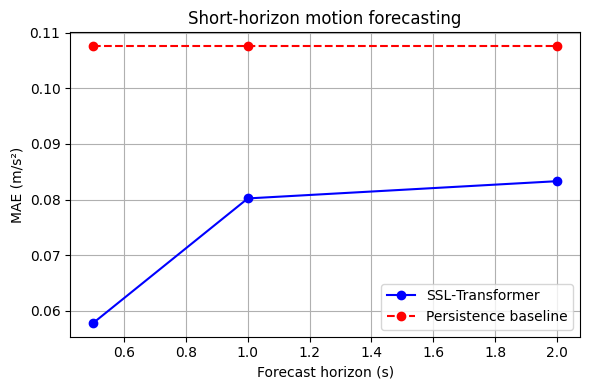

In [9]:
import numpy as np
import matplotlib.pyplot as plt

horizons = [0.5, 1.0, 2.0]
model_mae = [0.0578, 0.0802, 0.0833]   # from your printout
baseline_mae = [0.1076, 0.1076, 0.1076]

plt.figure(figsize=(6,4))
plt.plot(horizons, model_mae, "bo-", label="SSL‑Transformer")
plt.plot(horizons, baseline_mae, "ro--", label="Persistence baseline")
plt.xlabel("Forecast horizon (s)")
plt.ylabel("MAE (m/s²)")
plt.title("Short‑horizon motion forecasting")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
def plot_forecast_zoom(x_ex, m_fc_ex, y_id, p_id, title_prefix="Example"):
    # Forecast
    x_in = x_ex.clone()
    x_in[m_fc_ex.unsqueeze(-1).expand_as(x_in)] = 0
    recon_ex, _ = mt_model(x_in)

    # Back to time, axis 0
    x_true = x_ex.detach().cpu().view(NUM_PATCHES, PATCH_SIZE, 3).numpy()
    x_pred = recon_ex.detach().cpu().view(NUM_PATCHES, PATCH_SIZE, 3).numpy()

    sig_true = x_true[:,:,0].reshape(-1)   # (1000,)
    sig_pred = x_pred[:,:,0].reshape(-1)

    # Last 2 s = last 200 samples
    sig_t = sig_true[-200:]
    sig_p = sig_pred[-200:]
    t = np.arange(200) / 100.0   # 0..2 s

    # Normalize per window for nicer shape
    mu = sig_t.mean()
    std = sig_t.std() + 1e-6
    sig_tn = (sig_t - mu) / std
    sig_pn = (sig_p - mu) / std

    plt.figure(figsize=(6,3))
    plt.plot(t, sig_tn, label="True", color="black", alpha=0.7)
    plt.plot(t, sig_pn, label="Forecast", color="tab:red", alpha=0.8)
    plt.xlabel("Time in forecast window (s)")
    plt.ylabel("Normalized accel x")
    plt.title(f"{title_prefix} – {CLASSES[y_id]} (pred: {CLASSES[p_id]})")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


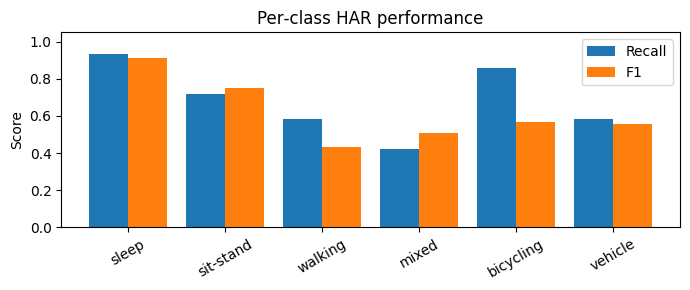

In [14]:
from sklearn.metrics import precision_recall_fscore_support

mask = np.array(y_true) != UNKNOWN_ID
yt = np.array(y_true)[mask]
yp = np.array(y_pred)[mask]

prec, rec, f1, supp = precision_recall_fscore_support(
    yt, yp, labels=list(range(NUM_CLASSES-1))
)

x = np.arange(NUM_CLASSES-1)
plt.figure(figsize=(7,3))
plt.bar(x - 0.2, rec, width=0.4, label="Recall")
plt.bar(x + 0.2, f1,  width=0.4, label="F1")
plt.xticks(x, CLASSES[:-1], rotation=30)
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.title("Per‑class HAR performance")
plt.legend()
plt.tight_layout()
plt.show()


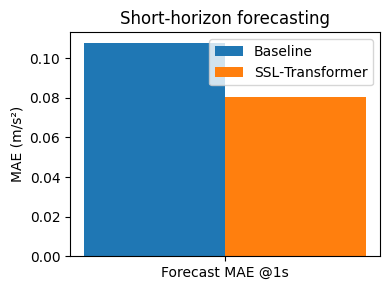

Baseline MAE @1s: 0.1076
Model MAE   @1s: 0.0802
Improvement: 25.5%


In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Use stored fc_errors and baseline_errs from evaluation
mae_1s = np.mean(fc_errors["1.0s"])
base_mae = np.mean(baseline_errs)

labels = ["Forecast MAE @1s"]
baseline_vals = [base_mae]
ssl_vals      = [mae_1s]

x = np.arange(len(labels))
w = 0.35

plt.figure(figsize=(4,3))
plt.bar(x - w/2, baseline_vals, width=w, label="Baseline")
plt.bar(x + w/2, ssl_vals,      width=w, label="SSL‑Transformer")
plt.xticks(x, labels)
plt.ylabel("MAE (m/s²)")
plt.title("Short‑horizon forecasting")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Baseline MAE @1s: {base_mae:.4f}")
print(f"Model MAE   @1s: {mae_1s:.4f}")
print(f"Improvement: {(base_mae - mae_1s)/base_mae*100:.1f}%")


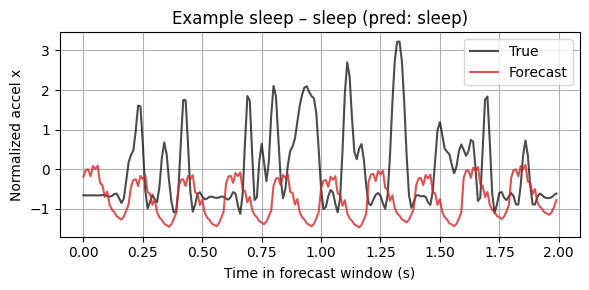

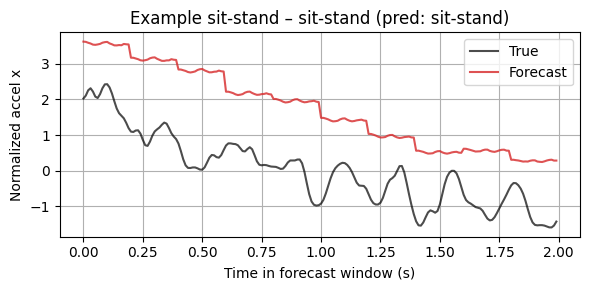

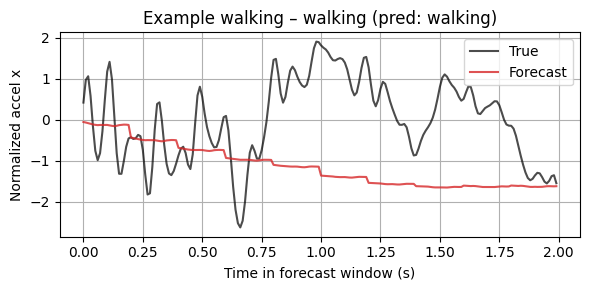

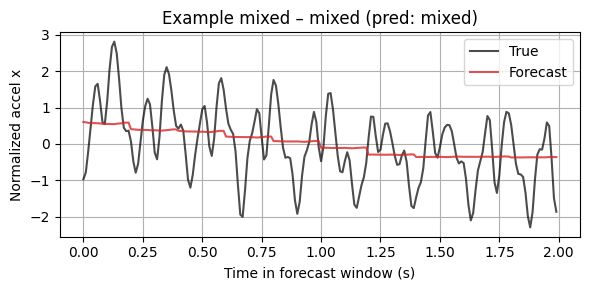

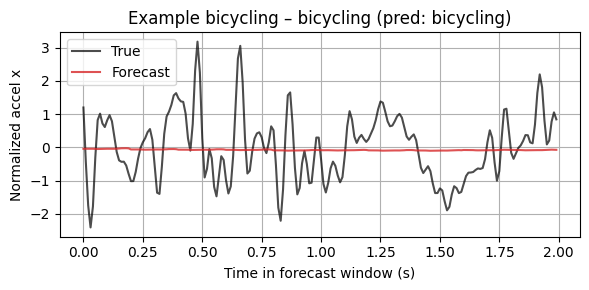

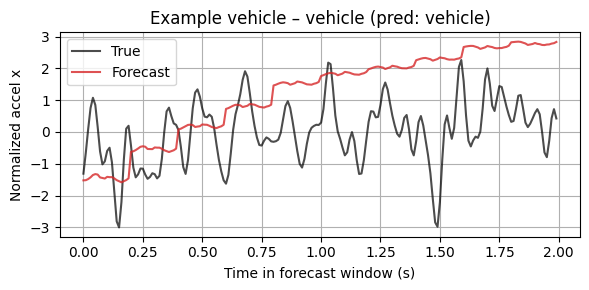

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import torch

mt_model.eval()

def plot_forecast_zoom(x_ex, m_fc_ex, y_id, p_id, title_prefix="Example"):
    x_in = x_ex.clone()
    x_in[m_fc_ex.unsqueeze(-1).expand_as(x_in)] = 0
    with torch.no_grad():
        recon_ex, _ = mt_model(x_in)

    x_true = x_ex.detach().cpu().view(NUM_PATCHES, PATCH_SIZE, 3).numpy()
    x_pred = recon_ex.detach().cpu().view(NUM_PATCHES, PATCH_SIZE, 3).numpy()

    sig_true = x_true[:,:,0].reshape(-1)
    sig_pred = x_pred[:,:,0].reshape(-1)

    sig_t = sig_true[-200:]   # last 2s @100Hz
    sig_p = sig_pred[-200:]
    t = np.arange(200) / 100.0

    mu = sig_t.mean()
    std = sig_t.std() + 1e-6
    sig_tn = (sig_t - mu) / std
    sig_pn = (sig_p - mu) / std

    plt.figure(figsize=(6,3))
    plt.plot(t, sig_tn, label="True", color="black", alpha=0.7)
    plt.plot(t, sig_pn, label="Forecast", color="tab:red", alpha=0.8)
    plt.xlabel("Time in forecast window (s)")
    plt.ylabel("Normalized accel x")
    plt.title(f"{title_prefix} – {CLASSES[y_id]} (pred: {CLASSES[p_id]})")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# one correctly classified example per known class
targets = {c: None for c in range(len(CLASSES)-1)}

with torch.no_grad():
    for x_batch, _, m_fc_batch, y_batch in test_loader:
        x_batch = x_batch.to(DEVICE)
        m_fc_batch = m_fc_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        x_in = x_batch.clone()
        x_in[m_fc_batch.unsqueeze(-1).expand_as(x_in)] = 0
        _, logits = mt_model(x_in)
        preds = logits.argmax(1)

        for i in range(x_batch.size(0)):
            y_i = y_batch[i].item()
            p_i = preds[i].item()
            if y_i == UNKNOWN_ID or y_i != p_i:
                continue
            if targets[y_i] is None:
                targets[y_i] = (x_batch[i:i+1], m_fc_batch[i:i+1], y_i, p_i)
        if all(v is not None for v in targets.values()):
            break

for c in range(len(CLASSES)-1):
    x_ex, m_fc_ex, y_id, p_id = targets[c]
    plot_forecast_zoom(x_ex, m_fc_ex, y_id, p_id, title_prefix=f"Example {CLASSES[c]}")


In [23]:
import torch
import numpy as np

mt_model.eval()

# Want one example for each known class (0..5), skipping 'unknown'
picked = {c: None for c in range(len(CLASSES)-1)}  # {class_id: (true_id, pred_id, conf)}

with torch.no_grad():
    for x_batch, _, _, y_batch in test_loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        _, logits = mt_model(x_batch)
        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(1)

        for i in range(x_batch.size(0)):
            true_id = y_batch[i].item()
            pred_id = preds[i].item()
            if true_id == UNKNOWN_ID:
                continue
            # store the *first* example of each true class
            if picked[true_id] is None:
                conf = probs[i, pred_id].item()
                picked[true_id] = (true_id, pred_id, conf)
        if all(v is not None for v in picked.values()):
            break

# Print one example per class
for c in range(len(CLASSES)-1):
    true_id, pred_id, conf = picked[c]
    print(f"Class {CLASSES[c]} example:")
    print(f"  True label : {CLASSES[true_id]}")
    print(f"  Pred label : {CLASSES[pred_id]}")
    print(f"  Confidence: {conf*100:.1f}%")
    print("-"*40)


Class sleep example:
  True label : sleep
  Pred label : sleep
  Confidence: 66.3%
----------------------------------------
Class sit-stand example:
  True label : sit-stand
  Pred label : walking
  Confidence: 58.3%
----------------------------------------
Class walking example:
  True label : walking
  Pred label : walking
  Confidence: 41.1%
----------------------------------------
Class mixed example:
  True label : mixed
  Pred label : mixed
  Confidence: 95.4%
----------------------------------------
Class bicycling example:
  True label : bicycling
  Pred label : bicycling
  Confidence: 98.6%
----------------------------------------
Class vehicle example:
  True label : vehicle
  Pred label : sit-stand
  Confidence: 51.9%
----------------------------------------
